# So sánh 3 mô hình YOLO 

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# CELL 1: KHAI BÁO ĐƯỜNG DẪN
# =========================================================

ROOT_DIR = Path(r"C:\Users\dungt\Downloads\BCKLTN")
YOLOV5_DIR = Path(r"C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov5\YOLOv5n")

MODEL_DIRS = {
    "YOLOv5n": YOLOV5_DIR,
    "YOLOv8n": Path(r"C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov8\YOLOv8n"),
    "YOLO11n": Path(r"C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov11\YOLO11n"),
}

# Thư mục lưu bảng và biểu đồ so sánh
OUTPUT_DIR = Path(r"C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT_DIR: C:\Users\dungt\Downloads\BCKLTN
OUTPUT_DIR: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo


In [3]:
# CELL 2: HÀM TỰ TÌM THƯ MỤC MODEL 
# =========================================================

def auto_find_model_dir(root_dir, model_keywords):
    """
    Tự tìm thư mục chứa results.csv theo tên model.
    Ví dụ: YOLOv5n, YOLOv8n, YOLO11n.
    """
    root_dir = Path(root_dir)

    if not root_dir.exists():
        return None

    all_results = list(root_dir.rglob("results.csv"))

    for csv_path in all_results:
        folder_name = csv_path.parent.name.lower()
        full_path = str(csv_path.parent).lower()

        for kw in model_keywords:
            if kw.lower() in folder_name or kw.lower() in full_path:
                return csv_path.parent

    return None


def ensure_model_dir(model_name, current_path):
    current_path = Path(current_path)

    if (current_path / "results.csv").exists():
        return current_path

    keywords = {
        "YOLOv5n": ["yolov5n", "yolo5n", "v5n"],
        "YOLOv8n": ["yolov8n", "yolo8n", "v8n"],
        "YOLO11n": ["yolo11n", "yolov11n", "v11n", "11n"],
    }

    found = auto_find_model_dir(ROOT_DIR, keywords.get(model_name, [model_name]))

    return found

In [4]:
# CELL 3: HÀM ĐỌC CHỈ SỐ TỪ results.csv
# =========================================================

def read_yolo_metrics(result_dir):
    result_dir = Path(result_dir)
    csv_path = result_dir / "results.csv"

    if not csv_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file results.csv tại: {csv_path}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.astype(str).str.strip()

    required_cols = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"File {csv_path} thiếu cột: {missing_cols}")

    last = df.iloc[-1]

    precision = float(last["metrics/precision(B)"])
    recall = float(last["metrics/recall(B)"])
    map50 = float(last["metrics/mAP50(B)"])
    map50_95 = float(last["metrics/mAP50-95(B)"])
    f1_score = 2 * precision * recall / (precision + recall + 1e-16)

    return {
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1_score,
        "mAP50": map50,
        "mAP50-95": map50_95,
        "Result dir": str(result_dir),
        "CSV file": str(csv_path)
    }, df

In [5]:
# CELL 4: ĐỌC KẾT QUẢ 3 MODEL
# =========================================================

comparison_rows = []
history_data = {}
final_model_dirs = {}

for model_name, model_path in MODEL_DIRS.items():
    final_dir = ensure_model_dir(model_name, model_path)

    if final_dir is None:
        print(f"Không tìm thấy kết quả của {model_name}. Hãy kiểm tra lại đường dẫn.")
        continue

    try:
        metrics, history_df = read_yolo_metrics(final_dir)

        row = {"Model": model_name}
        row.update(metrics)

        comparison_rows.append(row)
        history_data[model_name] = history_df
        final_model_dirs[model_name] = Path(final_dir)

        print(f"Đã đọc {model_name}: {final_dir}")

    except Exception as e:
        print(f"Lỗi khi đọc {model_name}: {e}")

comparison_df = pd.DataFrame(comparison_rows)

if comparison_df.empty:
    raise FileNotFoundError("Không đọc được kết quả của model nào. Hãy kiểm tra đường dẫn các thư mục kết quả.")

comparison_df = comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("\n===== BẢNG SO SÁNH 3 MODEL YOLO =====")
display(comparison_df)

Đã đọc YOLOv5n: C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov5\YOLOv5n
Đã đọc YOLOv8n: C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov8\YOLOv8n
Đã đọc YOLO11n: C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov11\YOLO11n

===== BẢNG SO SÁNH 3 MODEL YOLO =====


,Model,Precision,Recall,F1-score,mAP50,mAP50-95,Result dir,CSV file
0,YOLO11n,0.86501,0.88705,0.875891,0.85543,0.60243,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov1...,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov1...
1,YOLOv8n,0.86719,0.87809,0.872606,0.85193,0.60208,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov8...,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov8...
2,YOLOv5n,0.85861,0.86666,0.862616,0.84444,0.59161,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov5...,C:\Users\dungt\Downloads\BCKLTN\ket_qua_yolov5...


In [6]:
# CELL 5: LƯU BẢNG SO SÁNH
# =========================================================

csv_out = OUTPUT_DIR / "comparison_3_yolo_models.csv"
excel_out = OUTPUT_DIR / "comparison_3_yolo_models.xlsx"

comparison_df.to_csv(csv_out, index=False, encoding="utf-8-sig")

try:
    comparison_df.to_excel(excel_out, index=False)
    print("Đã lưu Excel:", excel_out)
except Exception as e:
    print("Không lưu được Excel. Có thể thiếu openpyxl. Lỗi:", e)

print("Đã lưu CSV:", csv_out)

Đã lưu Excel: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_3_yolo_models.xlsx
Đã lưu CSV: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_3_yolo_models.csv


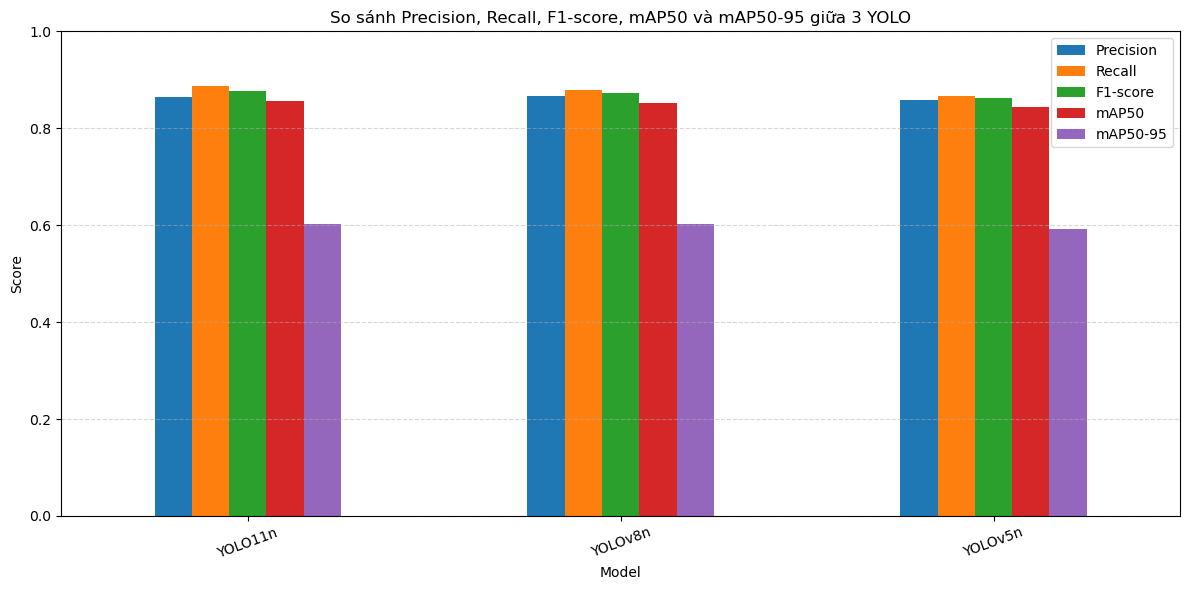

Đã lưu biểu đồ: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_all_metrics_yolo.png


In [7]:
# CELL 6: VẼ BIỂU ĐỒ GỘP CÁC CHỈ SỐ
# =========================================================

metrics_to_plot = ["Precision", "Recall", "F1-score", "mAP50", "mAP50-95"]

plot_df = comparison_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("So sánh Precision, Recall, F1-score, mAP50 và mAP50-95 giữa 3 YOLO")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

save_path = OUTPUT_DIR / "comparison_all_metrics_yolo.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ:", save_path)

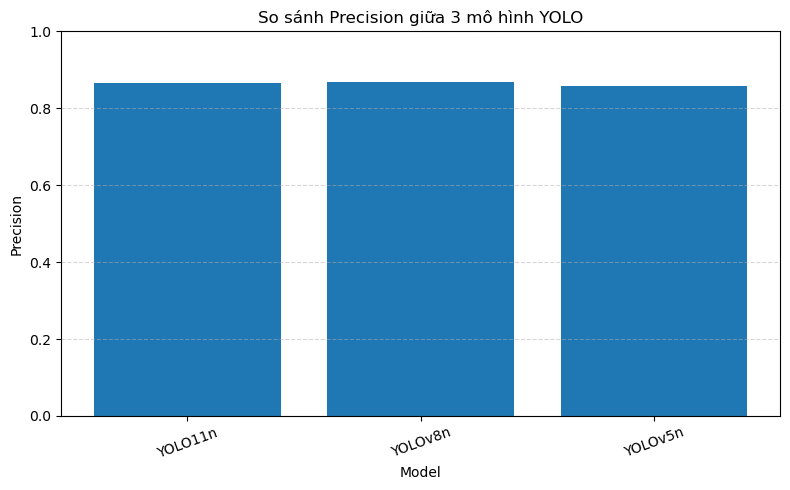

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_precision_yolo.png


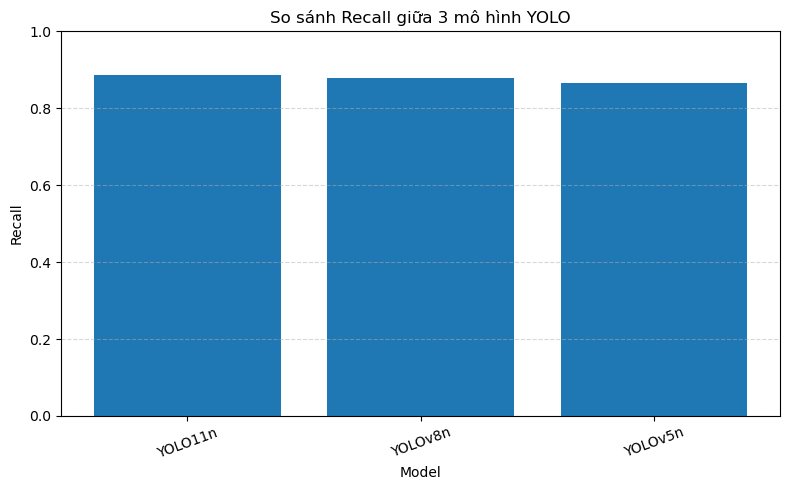

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_recall_yolo.png


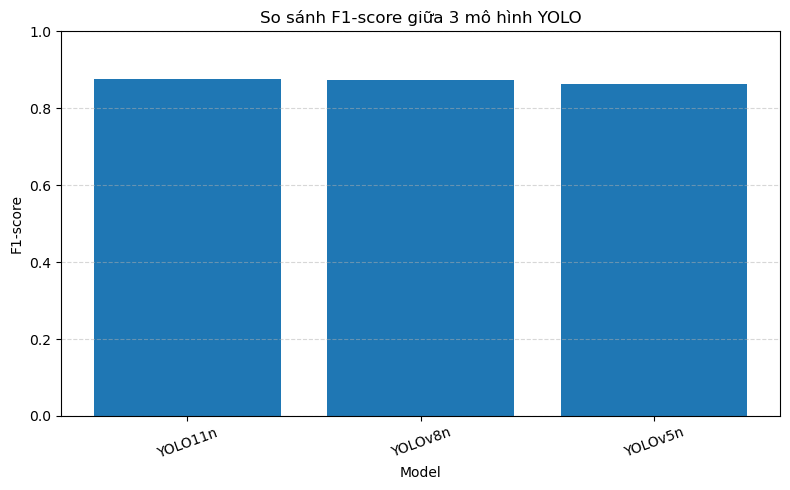

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_f1_score_yolo.png


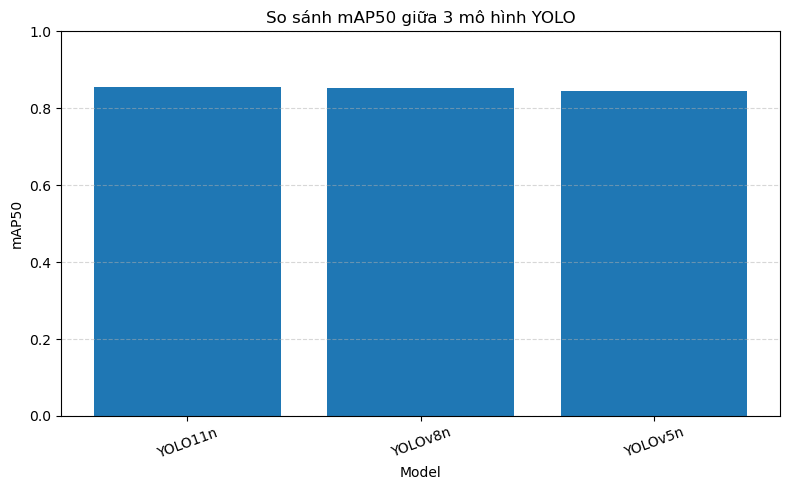

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_map50_yolo.png


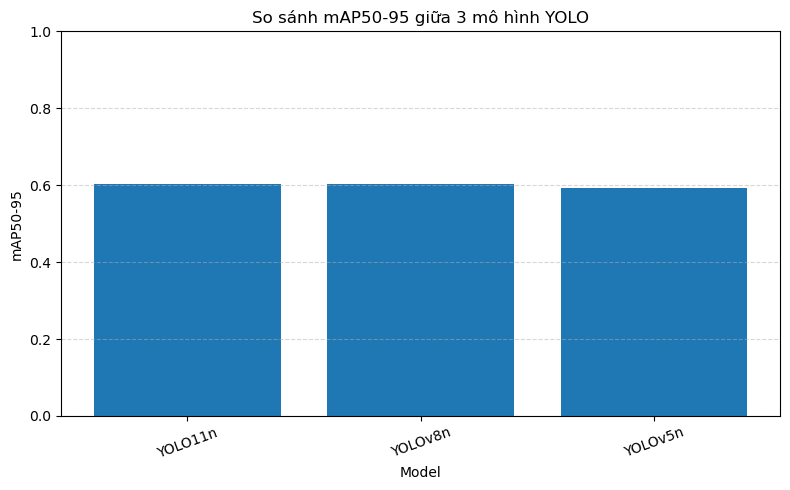

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\comparison_map50_95_yolo.png


In [8]:
# CELL 7: VẼ RIÊNG TỪNG CHỈ SỐ
# =========================================================

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])

    plt.title(f"So sánh {metric} giữa 3 mô hình YOLO")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    safe_metric = metric.replace("-", "_").replace("/", "_").lower()
    save_path = OUTPUT_DIR / f"comparison_{safe_metric}_yolo.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Đã lưu:", save_path)

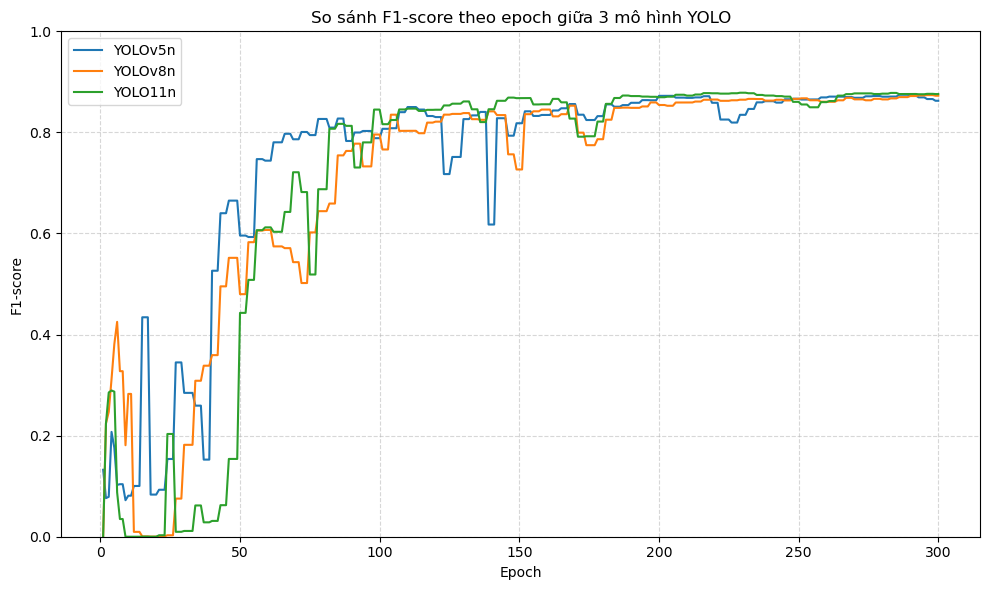

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\f1_score_by_epoch_yolo.png


In [9]:
# CELL 8: VẼ F1-SCORE THEO EPOCH
# =========================================================

plt.figure(figsize=(10, 6))

for model_name, df in history_data.items():
    df.columns = df.columns.astype(str).str.strip()

    epoch = df["epoch"] if "epoch" in df.columns else range(len(df))

    precision = df["metrics/precision(B)"]
    recall = df["metrics/recall(B)"]
    f1_score = 2 * precision * recall / (precision + recall + 1e-16)

    plt.plot(epoch, f1_score, label=model_name)

plt.title("So sánh F1-score theo epoch giữa 3 mô hình YOLO")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

save_path = OUTPUT_DIR / "f1_score_by_epoch_yolo.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", save_path)

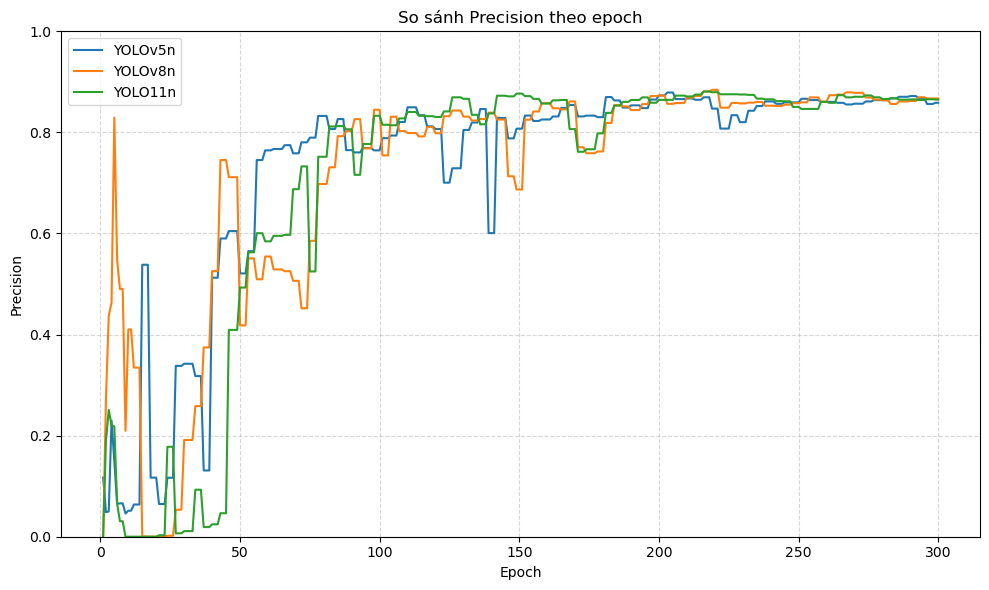

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\precision_by_epoch_yolo.png


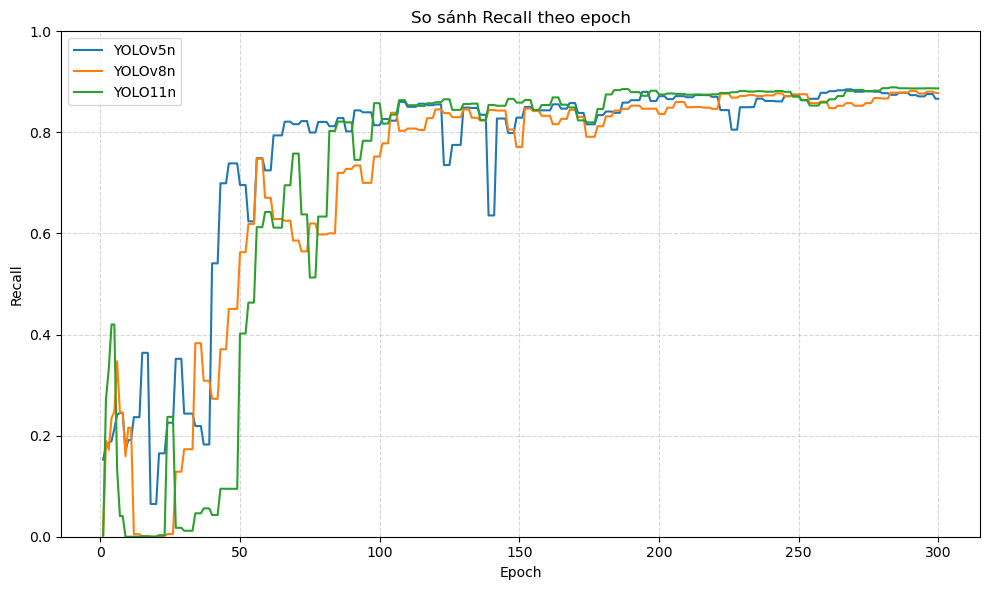

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\recall_by_epoch_yolo.png


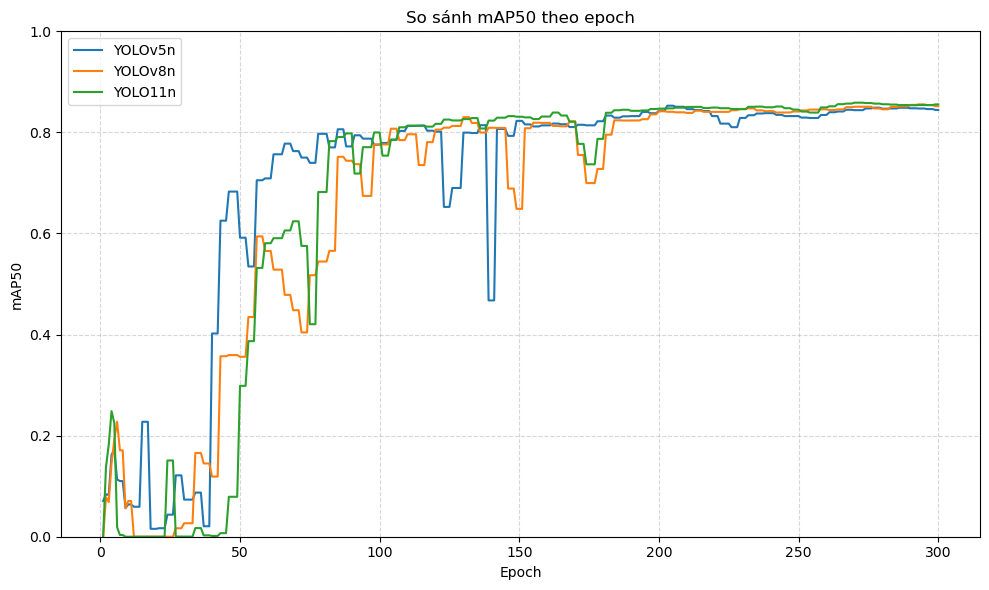

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\map50_by_epoch_yolo.png


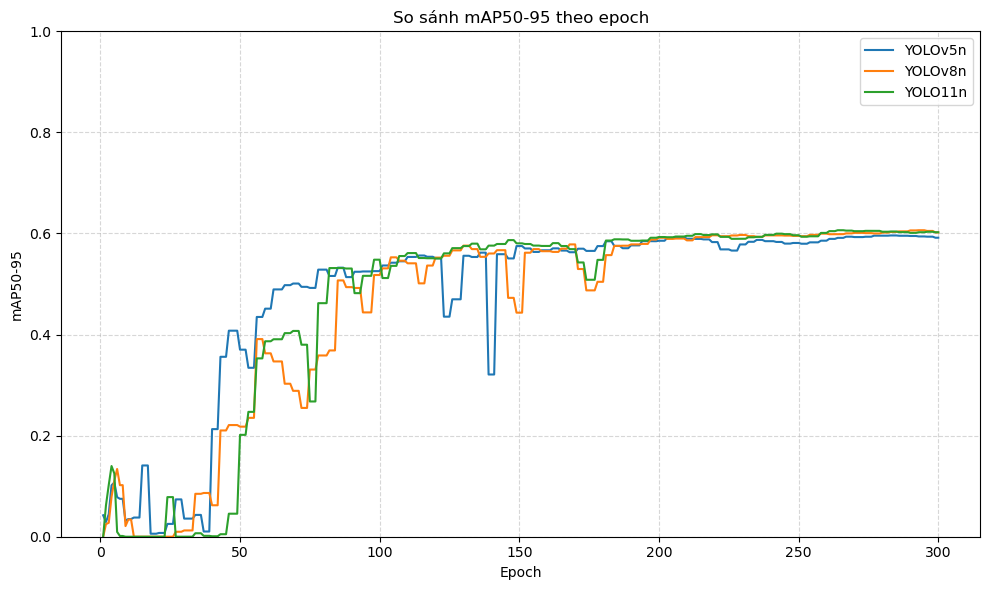

Đã lưu: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\map50_95_by_epoch_yolo.png


In [10]:
# CELL 9: VẼ PRECISION, RECALL, mAP THEO EPOCH
# =========================================================

epoch_metrics = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)"
}

for metric_name, column_name in epoch_metrics.items():
    plt.figure(figsize=(10, 6))

    for model_name, df in history_data.items():
        df.columns = df.columns.astype(str).str.strip()

        if column_name not in df.columns:
            continue

        epoch = df["epoch"] if "epoch" in df.columns else range(len(df))
        plt.plot(epoch, df[column_name], label=model_name)

    plt.title(f"So sánh {metric_name} theo epoch")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    save_name = metric_name.replace("-", "_").lower()
    save_path = OUTPUT_DIR / f"{save_name}_by_epoch_yolo.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Đã lưu:", save_path)


Ảnh kết quả của YOLO11n


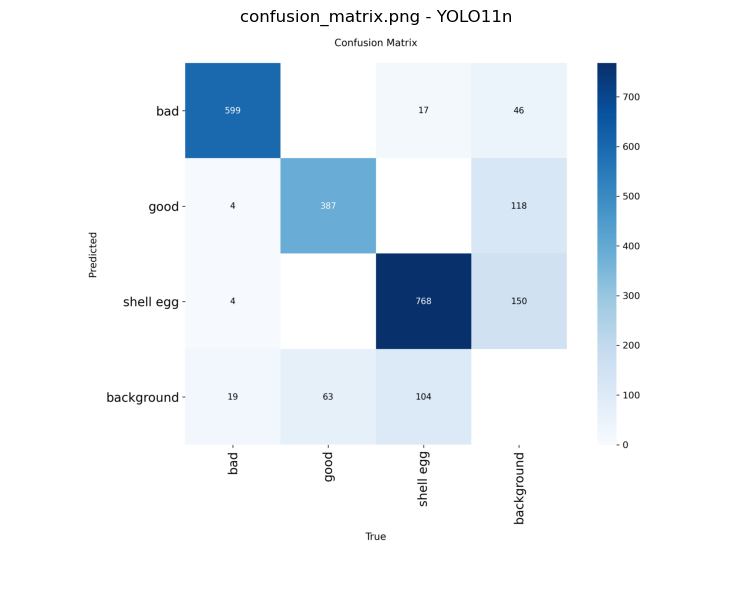

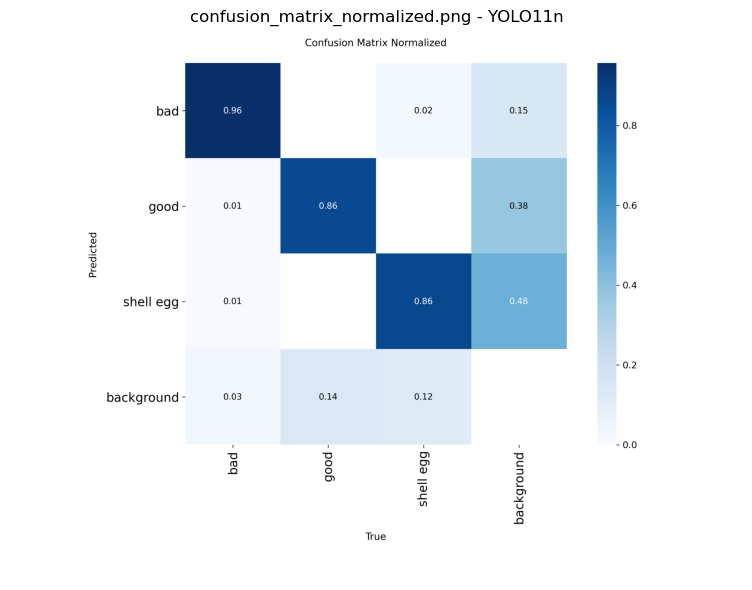

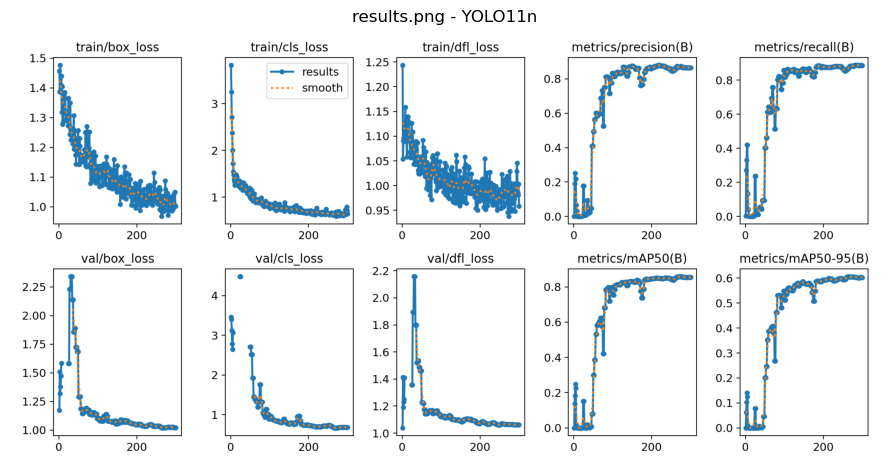


Ảnh kết quả của YOLOv8n


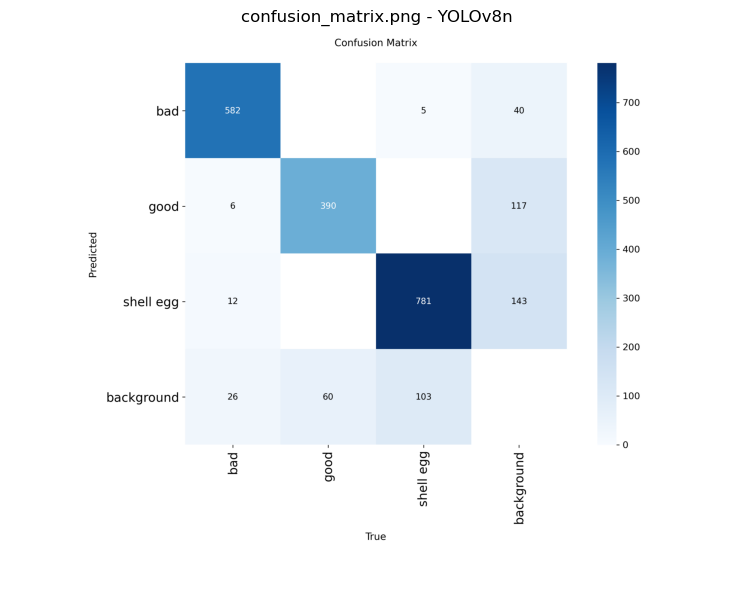

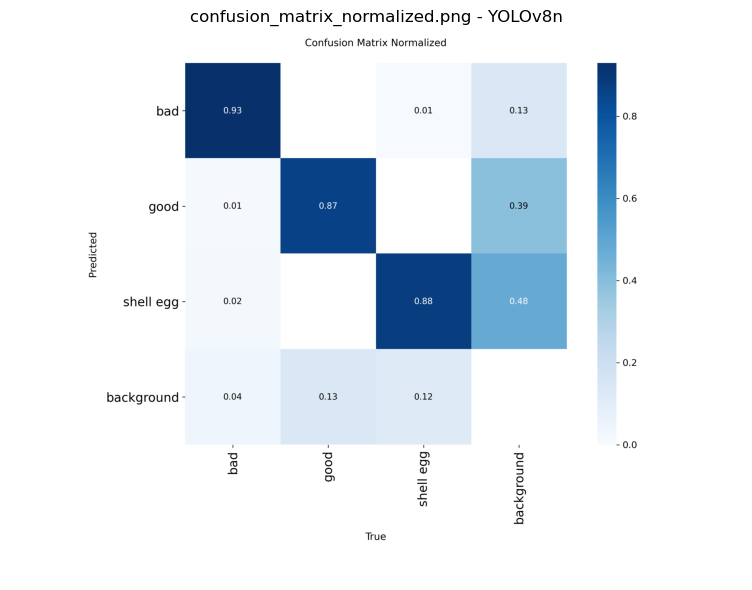

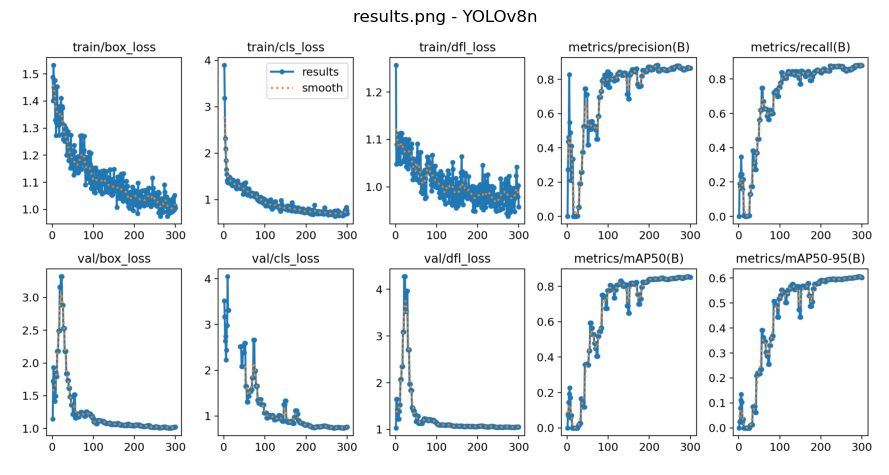


Ảnh kết quả của YOLOv5n


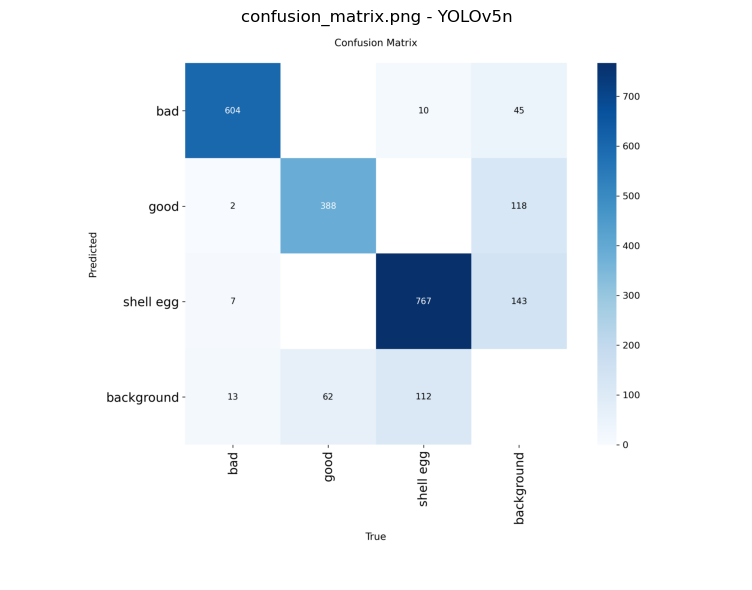

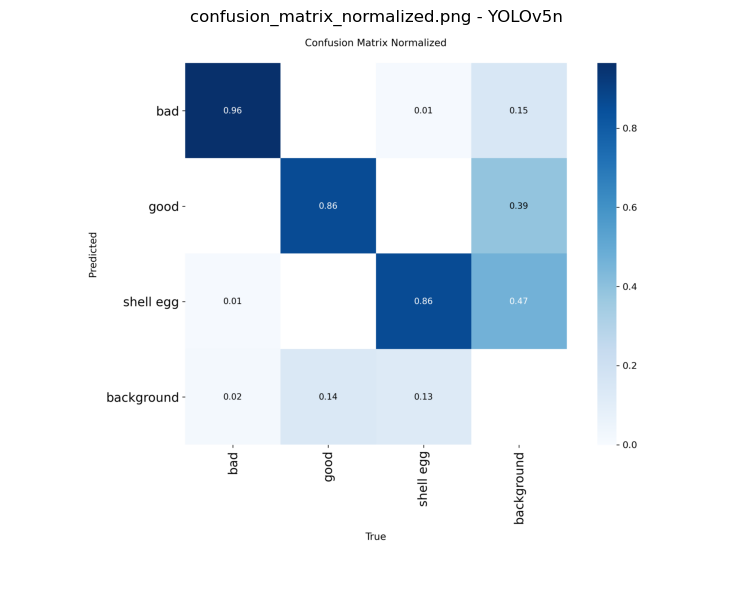

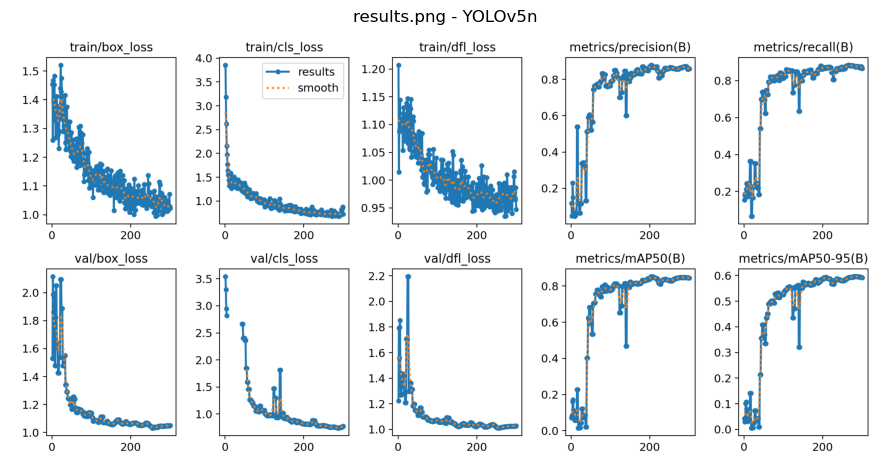

In [11]:
# CELL 10: HIỂN THỊ CONFUSION MATRIX VÀ CÁC BIỂU ĐỒ CÓ SẴN
# =========================================================

image_names = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "results.png"
]

for model_name in comparison_df["Model"]:
    result_dir = final_model_dirs.get(model_name)

    if result_dir is None:
        continue

    print("\n" + "=" * 60)
    print(f"Ảnh kết quả của {model_name}")
    print("=" * 60)

    for image_name in image_names:
        image_path = result_dir / image_name

        if not image_path.exists():
            continue

        img = Image.open(image_path)

        plt.figure(figsize=(9, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{image_name} - {model_name}")
        plt.tight_layout()
        plt.show()

In [12]:
# CELL 11: KẾT LUẬN TỰ ĐỘNG
# =========================================================

best_model = comparison_df.iloc[0]

summary_text = f"""
Kết quả so sánh cho thấy mô hình {best_model['Model']} đạt F1-score cao nhất,
với Precision = {best_model['Precision']:.4f}, Recall = {best_model['Recall']:.4f},
F1-score = {best_model['F1-score']:.4f}, mAP50 = {best_model['mAP50']:.4f}
và mAP50-95 = {best_model['mAP50-95']:.4f}. Do đó, trong phạm vi 3 mô hình YOLO
được thử nghiệm, {best_model['Model']} cho hiệu quả phát hiện và phân loại tốt nhất
trên tập đánh giá.
"""

summary_path = OUTPUT_DIR / "summary_best_yolo_model.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("Đã lưu nhận xét:", summary_path)
print("Toàn bộ kết quả so sánh được lưu tại:", OUTPUT_DIR)


Kết quả so sánh cho thấy mô hình YOLO11n đạt F1-score cao nhất,
với Precision = 0.8650, Recall = 0.8871,
F1-score = 0.8759, mAP50 = 0.8554
và mAP50-95 = 0.6024. Do đó, trong phạm vi 3 mô hình YOLO
được thử nghiệm, YOLO11n cho hiệu quả phát hiện và phân loại tốt nhất
trên tập đánh giá.

Đã lưu nhận xét: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo\summary_best_yolo_model.txt
Toàn bộ kết quả so sánh được lưu tại: C:\Users\dungt\Downloads\BCKLTN\so_sanh_3_yolo
